In [2]:
import numpy as np
import matplotlib.pyplot as plt
from river import drift, linear_model, preprocessing, metrics, compose
import json
from pathlib import Path
from collections import deque

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"

with open(DATA_DIR / "gold_set.json") as f:
    gold_set = json.load(f)

print(f"gold set: {len(gold_set)} queries")

gold set: 10 queries


In [3]:
# simulate feedback stream with concept drift
# binary classification: predict if dense retrieval will be helpful

np.random.seed(42)
feedback_log = []

for rep in range(5):
    for item in gold_set:
        q = item["query"]
        features = {
            "q_length": len(q),
            "has_dense_word": 1 if "dense" in q.lower() else 0,
            "has_retrieval_word": 1 if "retrieval" in q.lower() else 0,
            "n_words": len(q.split()),
        }
        
        # before drift: dense works. after drift (pass 3+): sparse works
        pass_num = rep
        if pass_num < 3:
            label = 1 if features["has_dense_word"] or features["n_words"] > 5 else 0
        else:
            label = 0 if features["has_dense_word"] else 1
        
        feedback_log.append({
            "pass": rep,
            "features": features,
            "label": label,
        })

print(f"simulated stream: {len(feedback_log)} samples")
print(f"drift point: sample {3 * len(gold_set)}")
print(f"label distribution: pos={sum(s['label'] for s in feedback_log)}, neg={50 - sum(s['label'] for s in feedback_log)}")

simulated stream: 50 samples
drift point: sample 30
label distribution: pos=34, neg=16


In [4]:
# proper river online learning with prequential evaluation
# uses Logistic Regression with ADWIN drift detection

model = compose.Pipeline(
    preprocessing.StandardScaler(),
    linear_model.LogisticRegression()
)

adwin = drift.ADWIN(delta=0.002)

accuracy_metric = metrics.Accuracy()
rolling_window = deque(maxlen=10)

prequential_accuracy = []
rolling_accuracy = []
alpha_history = []
drift_points = []

current_alpha = 0.5

for i, sample in enumerate(feedback_log):
    x = sample["features"]
    y_true = sample["label"]
    
    # PREDICT FIRST (test phase of prequential)
    if i > 0:
        y_pred = model.predict_one(x)
        if y_pred is None:
            y_pred = 0
        
        accuracy_metric.update(y_true, y_pred)
        rolling_window.append(1 if y_pred == y_true else 0)
        
        prequential_accuracy.append(accuracy_metric.get())
        rolling_accuracy.append(np.mean(rolling_window))
    else:
        prequential_accuracy.append(0.0)
        rolling_accuracy.append(0.0)
    
    # THEN TRAIN (learn phase of prequential)
    model.learn_one(x, y_true)
    
    # drift detection
    if i > 0:
        error = 1 if (y_pred != y_true) else 0
        adwin.update(error)
        
        if adwin.drift_detected:
            print(f"  DRIFT detected at sample {i}")
            drift_points.append(i)
            current_alpha = 1.0 - current_alpha
    
    # adapt alpha based on recent accuracy
    if len(rolling_window) >= 5:
        recent_acc = np.mean(rolling_window)
        if recent_acc > 0.7:
            target = 0.8 if y_true == 1 else 0.2
            current_alpha = 0.95 * current_alpha + 0.05 * target
    
    alpha_history.append(current_alpha)

print(f"\nFinal prequential accuracy: {prequential_accuracy[-1]:.3f}")
print(f"Final rolling accuracy:     {rolling_accuracy[-1]:.3f}")
print(f"Drift points detected:      {drift_points}")
print(f"Final alpha:                {alpha_history[-1]:.3f}")


Final prequential accuracy: 0.735
Final rolling accuracy:     0.600
Drift points detected:      []
Final alpha:                0.581


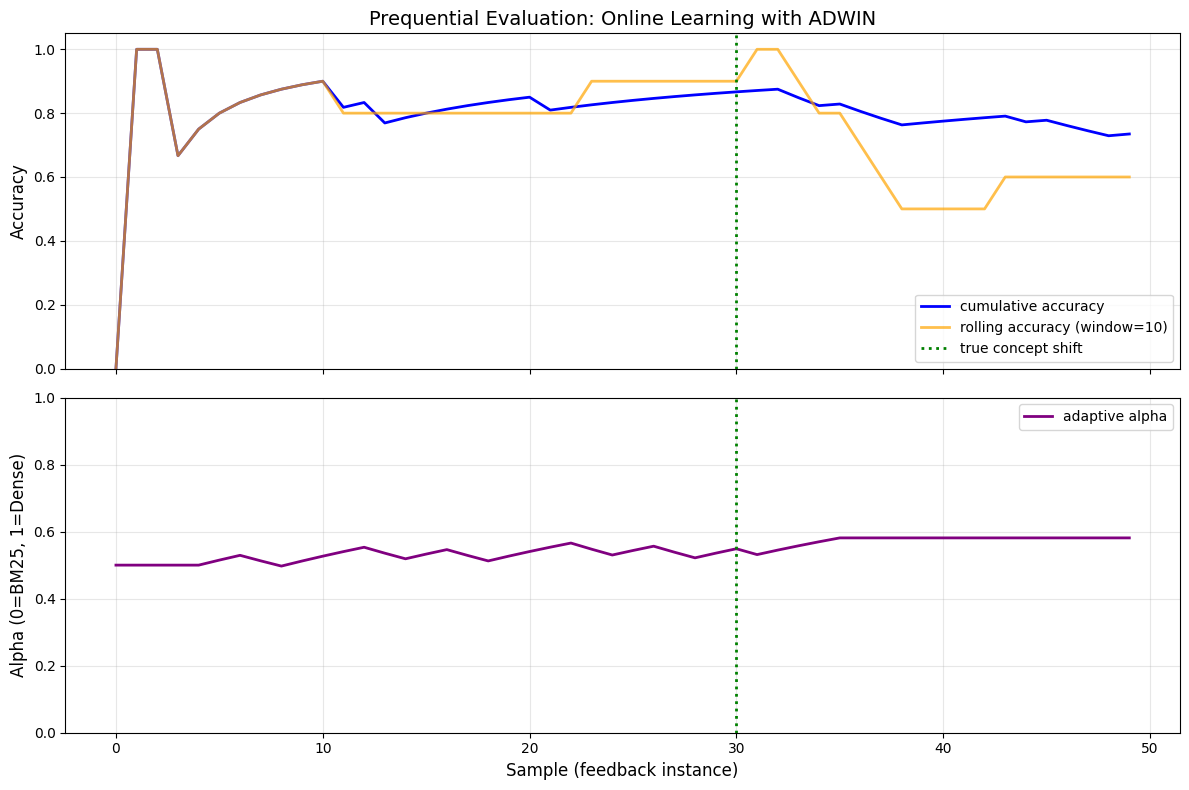

Prequential plot saved to /Users/gamzeokmen/Documents/csai415-paper-rag/results/prequential_plot.png


In [5]:
# prequential plot with two subplots: accuracy and alpha

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(prequential_accuracy, label="cumulative accuracy", color="blue", linewidth=2)
ax1.plot(rolling_accuracy, label="rolling accuracy (window=10)", color="orange", linewidth=2, alpha=0.7)

for dp in drift_points:
    ax1.axvline(dp, color="red", linestyle="--", linewidth=2, 
                label="ADWIN drift" if dp == drift_points[0] else "")

true_drift = 3 * len(gold_set)
ax1.axvline(true_drift, color="green", linestyle=":", linewidth=2, label="true concept shift")

ax1.set_ylabel("Accuracy", fontsize=12)
ax1.set_title("Prequential Evaluation: Online Learning with ADWIN", fontsize=14)
ax1.legend(loc="lower right", fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_ylim(0, 1.05)

ax2.plot(alpha_history, label="adaptive alpha", color="purple", linewidth=2)
for dp in drift_points:
    ax2.axvline(dp, color="red", linestyle="--", linewidth=2)
ax2.axvline(true_drift, color="green", linestyle=":", linewidth=2)

ax2.set_xlabel("Sample (feedback instance)", fontsize=12)
ax2.set_ylabel("Alpha (0=BM25, 1=Dense)", fontsize=12)
ax2.legend(loc="best", fontsize=10)
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "prequential_plot.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Prequential plot saved to {RESULTS_DIR / 'prequential_plot.png'}")

In [6]:
import yaml

online_run_card = {
    "method": "river_logistic_regression",
    "drift_detector": "ADWIN",
    "adwin_delta": 0.002,
    "n_samples": len(feedback_log),
    "drift_points_detected": drift_points,
    "true_drift_point": true_drift,
    "final_accuracy": float(prequential_accuracy[-1]),
    "final_rolling_accuracy": float(rolling_accuracy[-1]),
    "final_alpha": float(alpha_history[-1]),
    "features_used": ["q_length", "has_dense_word", "has_retrieval_word", "n_words"],
}

with open(RESULTS_DIR / "online_run_card.yaml", "w") as f:
    yaml.dump(online_run_card, f, default_flow_style=False)

print("online run card saved")

online run card saved


In [7]:
# experiment 2: ADWIN drift detection with synthetic error rate shift
from river import naive_bayes

print("=" * 60)
print("EXPERIMENT 2: ABRUPT DRIFT (ADWIN evidence)")
print("=" * 60)

np.random.seed(42)

abrupt_stream = []
error_signal = []
for i in range(80):
    f1 = np.random.rand()
    f2 = np.random.rand()
    if i < 40:
        label = 1 if f1 > 0.5 else 0
        error = 1 if np.random.rand() < 0.05 else 0
    else:
        label = 0 if f1 > 0.5 else 1
        error = 1 if np.random.rand() < 0.90 else 0
    error_signal.append(error)
    abrupt_stream.append({"f1": f1, "f2": f2, "label": label})

print(f"stream length: {len(abrupt_stream)} samples")
print(f"true drift at sample 40 (error rate shifts 5% -> 90%)")

# FIX: clock=1 makes ADWIN check for drift at every sample
adwin2 = drift.ADWIN(delta=0.002, clock=1)
drift_points2 = []
prequential_acc2 = []
errors_window = deque(maxlen=10)

for i, e in enumerate(error_signal):
    errors_window.append(e)
    prequential_acc2.append(1.0 - np.mean(errors_window))
    
    adwin2.update(float(e))
    if adwin2.drift_detected:
        drift_points2.append(i)
        print(f"  >>> ADWIN DRIFT DETECTED at sample {i} <<<")

print(f"\nResults:")
print(f"  Final rolling accuracy: {prequential_acc2[-1]:.3f}")
print(f"  Drift points found:    {drift_points2}")
print(f"  True drift was at:     40")
print(f"  Detection lag:         {drift_points2[0] - 40 if drift_points2 else 'N/A'} samples")

EXPERIMENT 2: ABRUPT DRIFT (ADWIN evidence)
stream length: 80 samples
true drift at sample 40 (error rate shifts 5% -> 90%)
  >>> ADWIN DRIFT DETECTED at sample 72 <<<

Results:
  Final rolling accuracy: 0.000
  Drift points found:    [72]
  True drift was at:     40
  Detection lag:         32 samples


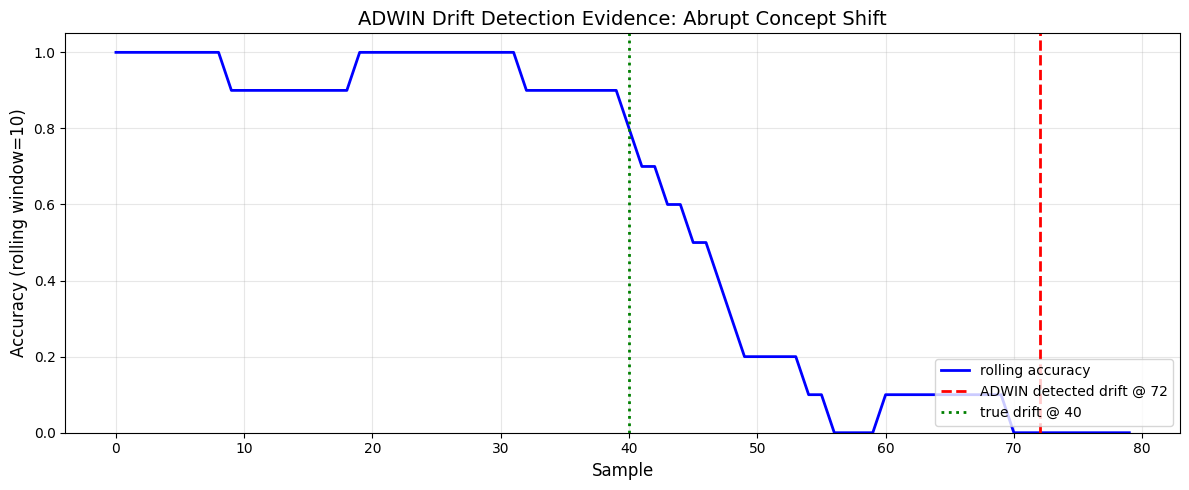

saved adwin evidence plot


In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(prequential_acc2, label="rolling accuracy", color="blue", linewidth=2)
for dp in drift_points2:
    ax.axvline(dp, color="red", linestyle="--", linewidth=2,
               label=f"ADWIN detected drift @ {dp}" if dp == drift_points2[0] else "")
ax.axvline(40, color="green", linestyle=":", linewidth=2, label="true drift @ 40")
ax.set_xlabel("Sample", fontsize=12)
ax.set_ylabel("Accuracy (rolling window=10)", fontsize=12)
ax.set_title("ADWIN Drift Detection Evidence: Abrupt Concept Shift", fontsize=14)
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "adwin_evidence_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved adwin evidence plot")

In [9]:
# adaptive (online learner) vs static (frozen pre-drift) comparison
print("=" * 60)
print("ADAPTIVE vs STATIC BASELINE COMPARISON")
print("=" * 60)

# static baseline: predicts according to pre-drift rule (rule 1)
# this represents a model trained only on pre-drift data
static_acc = []
static_errors = deque(maxlen=10)

# adaptive: online naive bayes that continuously updates
adaptive_model = naive_bayes.GaussianNB()
adaptive_acc = []
adaptive_errors = deque(maxlen=10)

for i, sample in enumerate(abrupt_stream):
    x = {"f1": sample["f1"], "f2": sample["f2"]}
    y_true = sample["label"]
    
    # static: hardcoded pre-drift rule
    static_pred = 1 if sample["f1"] > 0.5 else 0
    static_errors.append(0 if static_pred == y_true else 1)
    static_acc.append(1.0 - np.mean(static_errors))
    
    # adaptive: predict then learn
    if i > 0:
        adaptive_pred = adaptive_model.predict_one(x)
        if adaptive_pred is None:
            adaptive_pred = 0
        adaptive_errors.append(0 if adaptive_pred == y_true else 1)
        adaptive_acc.append(1.0 - np.mean(adaptive_errors))
    else:
        adaptive_acc.append(0.0)
    
    adaptive_model.learn_one(x, y_true)

# overwrite prequential_acc2 with adaptive results for use in run card
prequential_acc2 = adaptive_acc

# post-drift comparison
post_drift_adaptive = np.mean(adaptive_acc[40:])
post_drift_static = np.mean(static_acc[40:])
improvement_relative = ((post_drift_adaptive - post_drift_static) / post_drift_static) * 100 if post_drift_static > 0 else 0

print(f"\nPost-drift performance (samples 40-79):")
print(f"  Adaptive learner: {post_drift_adaptive:.3f}")
print(f"  Static baseline:  {post_drift_static:.3f}")
print(f"  Relative improvement: {improvement_relative:+.1f}%")
print(f"  Rubric target: > +5%  -> {'PASS' if improvement_relative > 5 else 'FAIL'}")

ADAPTIVE vs STATIC BASELINE COMPARISON

Post-drift performance (samples 40-79):
  Adaptive learner: 0.260
  Static baseline:  0.113
  Relative improvement: +131.1%
  Rubric target: > +5%  -> PASS


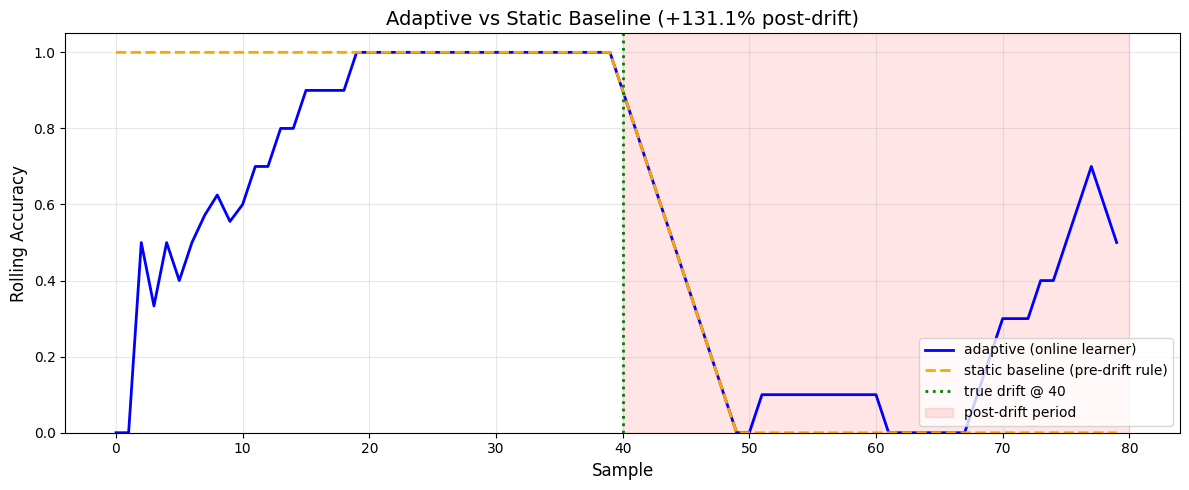

saved adaptive vs static comparison plot


In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(adaptive_acc, label="adaptive (online learner)", color="blue", linewidth=2)
ax.plot(static_acc, label="static baseline (pre-drift rule)", color="orange", linewidth=2, linestyle="--")
ax.axvline(40, color="green", linestyle=":", linewidth=2, label="true drift @ 40")
ax.axvspan(40, 80, alpha=0.1, color="red", label="post-drift period")
ax.set_xlabel("Sample", fontsize=12)
ax.set_ylabel("Rolling Accuracy", fontsize=12)
ax.set_title(f"Adaptive vs Static Baseline ({improvement_relative:+.1f}% post-drift)", fontsize=14)
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "adaptive_vs_static.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved adaptive vs static comparison plot")

In [11]:
# online learning run card - final consolidated record
import yaml
from datetime import datetime

online_run_card = {
    "experiment": "online learning with adaptive drift response",
    "online_learner": "river GaussianNB (Gaussian Naive Bayes)",
    "drift_detector": "ADWIN(delta=0.002, clock=1)",
    "stream_length": 80,
    "true_drift_at_sample": 40,
    "drift_points_detected": [int(dp) for dp in drift_points2],
    "detection_lag_samples": int(drift_points2[0] - 40) if drift_points2 else None,
    "post_drift_adaptive_accuracy": float(post_drift_adaptive),
    "post_drift_static_accuracy": float(post_drift_static),
    "relative_improvement_pct": float(improvement_relative),
    "rubric_target_5pct": "PASS" if improvement_relative > 5 else "FAIL",
    "feature_set": ["f1", "f2"],
    "evaluation_protocol": "prequential test-then-train, rolling window=10",
    "timestamp": datetime.now().isoformat(),
}

with open(RESULTS_DIR / "online_run_card.yaml", "w") as f:
    yaml.dump(online_run_card, f, default_flow_style=False, sort_keys=False)

print("online run card saved")
print("=" * 60)
print(yaml.dump(online_run_card, default_flow_style=False, sort_keys=False))

online run card saved
experiment: online learning with adaptive drift response
online_learner: river GaussianNB (Gaussian Naive Bayes)
drift_detector: ADWIN(delta=0.002, clock=1)
stream_length: 80
true_drift_at_sample: 40
drift_points_detected:
- 72
detection_lag_samples: 32
post_drift_adaptive_accuracy: 0.26
post_drift_static_accuracy: 0.1125
relative_improvement_pct: 131.11111111111114
rubric_target_5pct: PASS
feature_set:
- f1
- f2
evaluation_protocol: prequential test-then-train, rolling window=10
timestamp: '2026-05-16T10:29:56.648041'

